In [134]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.metrics import ConfusionMatrixDisplay


In [64]:
df = pd.read_excel('features.xlsx')

,composition,classification,regression Eg (eV),MagpieData minimum Number,MagpieData maximum Number,MagpieData range Number,MagpieData mean Number,MagpieData avg_dev Number,MagpieData mode Number,MagpieData minimum MendeleevNumber,...,MagpieData range GSmagmom,MagpieData mean GSmagmom,MagpieData avg_dev GSmagmom,MagpieData mode GSmagmom,MagpieData minimum SpaceGroupNumber,MagpieData maximum SpaceGroupNumber,MagpieData range SpaceGroupNumber,MagpieData mean SpaceGroupNumber,MagpieData avg_dev SpaceGroupNumber,MagpieData mode SpaceGroupNumber
0,Ag0.825 Al0.175,metal,NaN,13,47,34,41.050000,9.817500,47,65,...,0.000000,0.000000,0.000000,0.0,225,225,0,225.000000,0.000000e+00,225
1,Ag0.82 Al0.18,metal,NaN,13,47,34,40.880000,10.036800,47,65,...,0.000000,0.000000,0.000000,0.0,225,225,0,225.000000,0.000000e+00,225
2,Ag0.818 Al0.182,metal,NaN,13,47,34,40.812000,10.123568,47,65,...,0.000000,0.000000,0.000000,0.0,225,225,0,225.000000,2.842171e-14,225
3,Ag0.803 Al0.197,metal,NaN,13,47,34,40.302000,10.756988,47,65,...,0.000000,0.000000,0.000000,0.0,225,225,0,225.000000,0.000000e+00,225
4,Ag0.79 Al0.21,metal,NaN,13,47,34,39.860000,11.281200,47,65,...,0.000000,0.000000,0.000000,0.0,225,225,0,225.000000,0.000000e+00,225
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94090,Sb1 Se1 Te1 Tl1,nonmetal,0.250073,34,81,47,54.500000,13.250000,34,76,...,0.000000,0.000000,0.000000,0.0,14,194,180,131.500000,5.875000e+01,14
94091,Sb3.6 Sm1 Sn0.4 Ti3,metal,NaN,22,62,40,41.450000,14.587500,51,23,...,0.000023,0.000008,0.000011,0.0,141,194,53,175.250000,1.406250e+01,166
94092,Se6 Si2 Ta15 Te4,metal,NaN,14,73,59,56.851852,17.942387,73,48,...,0.000000,0.000000,0.000000,0.0,14,229,215,169.666667,7.441975e+01,229
94093,Se0.05 Sn0.95 Te0.95 Zn0.05,nonmetal,1.085840,30,52,22,50.050000,1.852500,50,69,...,0.000000,0.000000,0.000000,0.0,14,194,180,144.375000,9.725000e+00,141


In [ ]:
# for classifier
# remove 'unassigned' classification
mask = df['classification'].isin(['metal', 'nonmetal'])

df_no_unassigned = df.loc[mask]

X_class = df_no_unassigned.drop(columns=['composition', 'classification', 'regression Eg (eV)'])
y_class = df_no_unassigned["classification"].map({"metal": 0,"nonmetal": 1})

In [75]:
# for regressor
# we only want 'nonmetal' for predicting band gap
mask = (df['classification'] == 'nonmetal') & (df['regression Eg (eV)'].notna())
X_reg = df.loc[mask]
X_reg = X_reg.drop(columns=['composition', 'classification', 'regression Eg (eV)'])
y_reg = df.loc[mask, 'regression Eg (eV)']


SVC

In [90]:
svc = Pipeline([("scaler", StandardScaler()),
                ("svc", SVC(kernel="rbf", probability=True, random_state=42))])

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)


In [92]:
# accuracy
acc_scores = cross_val_score(
    svc,
    X_class,
    y_class,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1)

# ROC-AUC
auc_scores = cross_val_score(
    svc,
    X_class,
    y_class,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1)

print("Accuracy scores:", acc_scores)
print("Mean accuracy:", acc_scores.mean())
print("Std accuracy:", acc_scores.std())

print("ROC-AUC scores:", auc_scores)
print("Mean ROC-AUC:", auc_scores.mean())
print("Std ROC-AUC:", auc_scores.std())

Accuracy scores: [0.88091354 0.88062566 0.88190135]
Mean accuracy: 0.8811468498581911
Std accuracy: 0.0005463036228155108
ROC-AUC scores: [0.94490941 0.94452892 0.9441056 ]
Mean ROC-AUC: 0.9445146446139513
Std ROC-AUC: 0.0003283117479697472


Training scores:

- Accuracy scores: [0.88282333 0.88495575 0.88154387 0.88516287 0.88345684]
- Mean accuracy: 0.8835885341690514
- Std accuracy: 0.0013513949204764259


- ROC-AUC scores: [0.94615103 0.94654768 0.94483315 0.94843435 0.94509823]
- Mean ROC-AUC: 0.9462128889893595
- Std ROC-AUC: 0.0012803868638977505

In [93]:
y_cpred = cross_val_predict(
    svc,
    X_class,
    y_class,
    cv=cv,
    method="predict",
    n_jobs=-1)

y_cprob = cross_val_predict(
    svc,
    X_class,
    y_class,
    cv=cv,
    method="predict_proba",
    n_jobs=-1)[:, 1]

print("Confusion Matrix:")
print(confusion_matrix(y_class, y_cpred))

print("Cross-validated ROC-AUC:", roc_auc_score(y_class, y_cprob))

Confusion Matrix:
[[59102  5307]
 [ 5840 23539]]
Cross-validated ROC-AUC: 0.9445027816352349


Text(0.5, 1.0, 'Confusion Matrix')

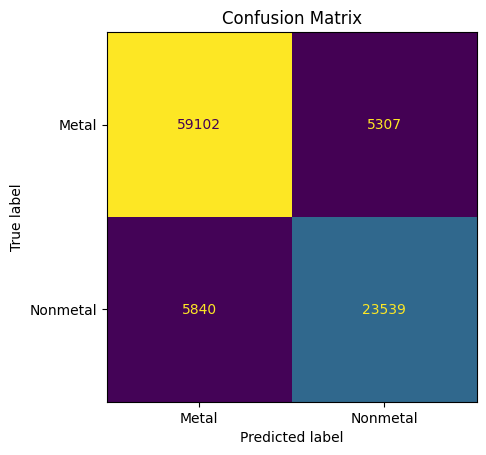

In [139]:
cm = confusion_matrix(y_class, y_cpred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["Metal", "Nonmetal"])
disp.plot(colorbar = False)
plt.title('Confusion Matrix')

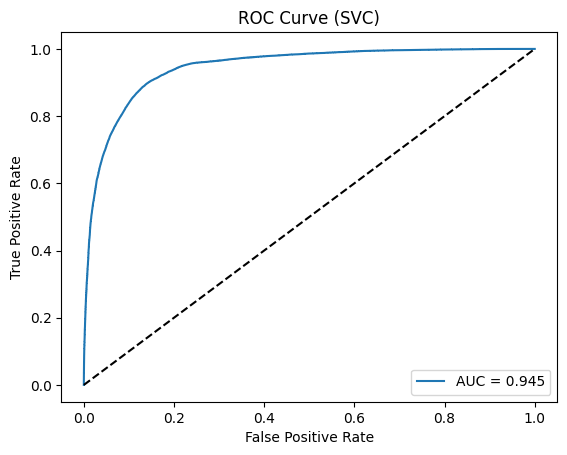

In [95]:
# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_class, y_cprob)

# Plot
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_class, y_cprob):.3f}")
plt.plot([0, 1], [0, 1], 'k--')  # random baseline

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (SVC)")
plt.legend()
plt.show()

SVR

In [107]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

In [100]:
X_reg.shape

(29379, 132)

In [104]:
# To prevent running the code for loooooong time I shorten the features and labels to find the best parameter.
X_small = X_reg.sample(5000, random_state=42)
y_small = y_reg.loc[X_small.index]

In [105]:
param = {"svr__C": [1, 10, 100],
              "svr__epsilon": [0.01, 0.1, 0.5],
              "svr__gamma": [0.001, 0.01, 0.1]}

cv = KFold(n_splits=3, shuffle=True, random_state=42)

svr = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR(kernel="rbf"))])

grid = GridSearchCV(
    svr,
    param,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1)

grid.fit(X_small, y_small)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...svr', SVR())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'svr__C': [1, 10, ...], 'svr__epsilon': [0.01, 0.1, ...], 'svr__gamma': [0.001, 0.01, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time fo

In [109]:
best_params = grid.best_params_
print(best_params)

{'svr__C': 10, 'svr__epsilon': 0.1, 'svr__gamma': 0.01}


In [110]:
# now using the best params, build a svr model
best_svr = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR(
        kernel="rbf",
        C=best_params["svr__C"],
        epsilon=best_params["svr__epsilon"],
        gamma=best_params["svr__gamma"]))])

In [ ]:
y_pred = cross_val_predict(best_svr, X_reg, y_reg, cv=cv, n_jobs=-1)

rmse = np.sqrt(mean_squared_error(y_reg, y_pred))
r2 = r2_score(y_reg, y_pred)

print("RMSE:", rmse)
print("R²:", r2)

RMSE: 0.3822604081797993
R²: 0.8950262767815566


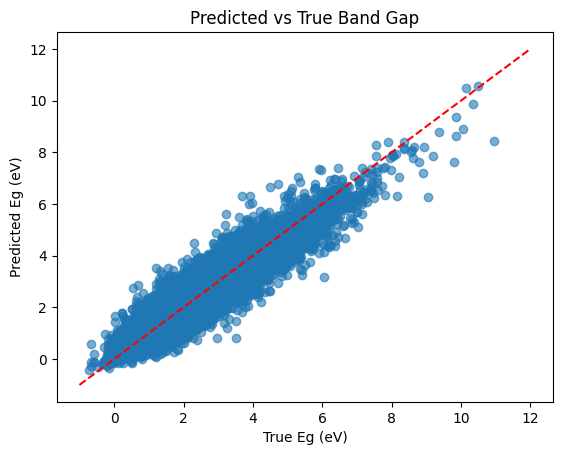

In [131]:
plt.scatter(y_reg, y_pred, alpha=0.6)
plt.plot(np.linspace(-1,12),np.linspace(-1,12),'r--')
plt.xlabel("True Eg (eV)")
plt.ylabel("Predicted Eg (eV)")
plt.title("Predicted vs True Band Gap")
plt.show()